In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("adult.csv")

In [3]:
df.shape

(48842, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [18]:
df.replace("?", np.nan, inplace=True)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df.drop_duplicates(inplace=True)

print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 0


<Axes: ylabel='age'>

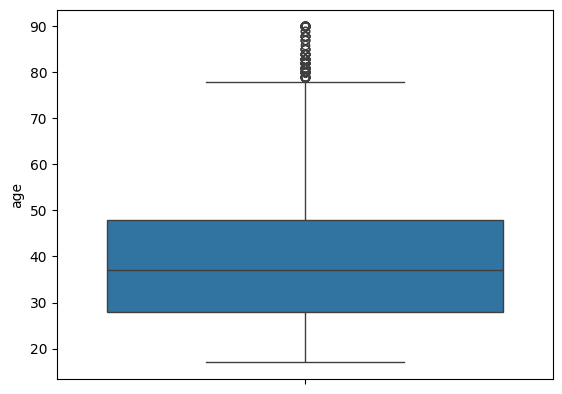

In [11]:
sns.boxplot(df['age'])

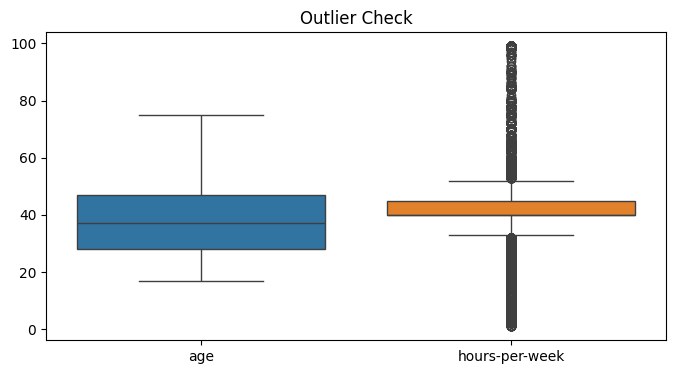

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[["age", "hours-per-week"]])
plt.title("Outlier Check")
plt.show()
df["hours-per-week"] = df["hours-per-week"].clip(1, 80)

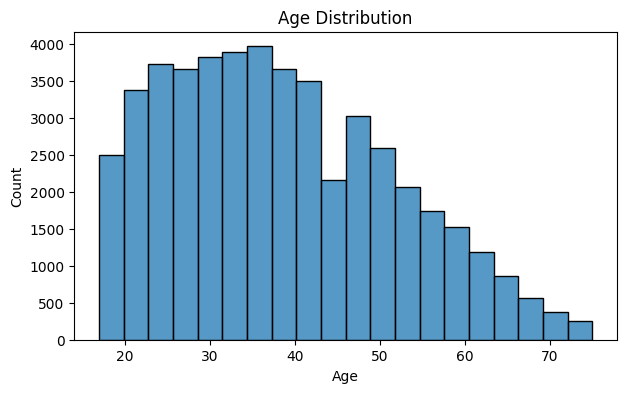

In [19]:
plt.figure(figsize=(7,4))

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

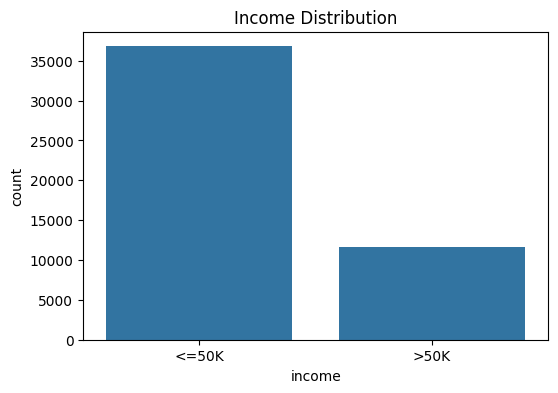

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="income", data=df)

plt.title("Income Distribution")

plt.show()

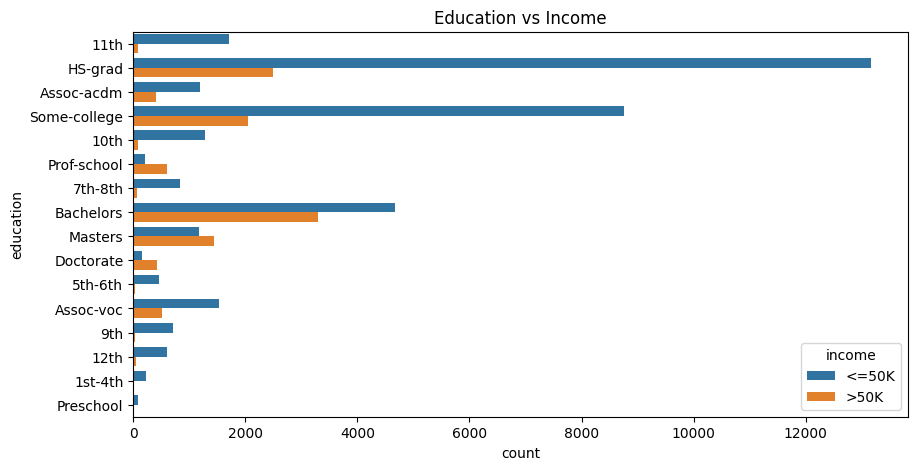

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="education",
    hue="income",
    data=df
)

plt.title("Education vs Income")

plt.show()

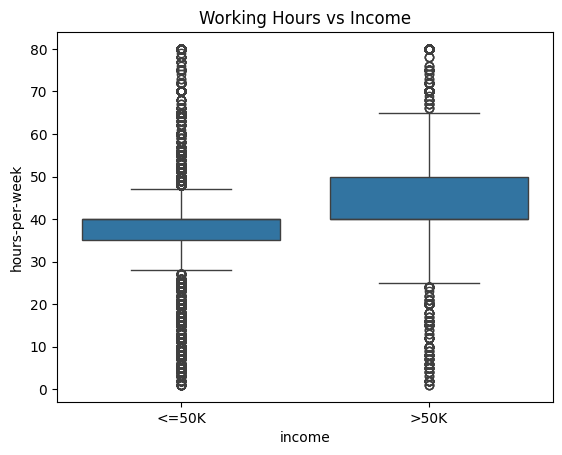

In [25]:
sns.boxplot(
    x="income",
    y="hours-per-week",
    data=df
)

plt.title("Working Hours vs Income")

plt.show()

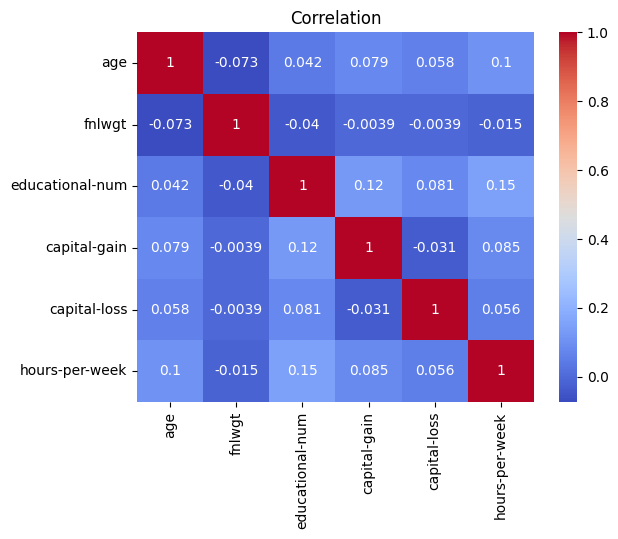

In [26]:
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation")

plt.show()

In [27]:
# Feature 1: Age Group

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Senior"]
)

In [28]:
# Feature 2: Net Capital

df["net_capital"] = (
    df["capital-gain"] - df["capital-loss"]
)

df[["age", "age_group", "net_capital"]].head()

,age,age_group,net_capital
0,25,Young,0
1,38,Middle,0
2,28,Young,0
3,44,Middle,7688
4,18,Young,0


# 5 KEY INSIGHTS

# 1. Most people in the dataset earn <=50K.

# 2. Higher education levels are generally related to higher income.

# 3. Middle-aged people are more likely to earn higher income.

# 4. People earning >50K generally work more hours per week.

# 5. Capital gain and capital loss can help predict income.






In [29]:
df.to_csv("cleaned_adult.csv", index=False)

print("Dataset cleaned successfully!")

Dataset cleaned successfully!
